In [9]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [10]:
df = pd.read_csv("../data/train.csv")

In [11]:
y = df.Survived
df = df.drop(columns=['Survived', 'PassengerId'])
num_cols = df.select_dtypes(exclude=['object']).columns

### Cabin feature

In [12]:
df['HasCabin'] = df.Cabin.notna().astype(int)

In [13]:
df['Deck'] = df['Cabin'].str[0].fillna('U')

In [14]:
df['CabinCount'] = (df['Cabin'].str.count(' ')+1).fillna(0).astype('int')

In [15]:
df = df.drop(columns=['Cabin'])

In [16]:
df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,Deck,CabinCount
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,U,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,C,1
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,U,0
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,C,1
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,U,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Name        891 non-null    object 
 2   Sex         891 non-null    object 
 3   Age         714 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Ticket      891 non-null    object 
 7   Fare        891 non-null    float64
 8   Embarked    889 non-null    object 
 9   HasCabin    891 non-null    int64  
 10  Deck        891 non-null    object 
 11  CabinCount  891 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Ticket feature

In [18]:
ticket_counts = df.Ticket.value_counts()
df['GroupSize'] = df.Ticket.map(ticket_counts)

In [19]:
df['TicketPrefix'] = (df['Ticket']
                        .str.split()
                        .apply(lambda x: x[0].replace('.', '').replace('/', '') 
                        if len(x)>1 else 'NoPrefix'))

In [20]:
df = df.drop(columns=['Ticket'])

In [21]:
treshhold = 0.005 
prefix_freq = df['TicketPrefix'].value_counts(normalize=True)
rare_prefixes = prefix_freq[prefix_freq < treshhold].index
rare_prefixes

Index(['SCParis', 'SOPP', 'SCAH', 'WEP', 'PP', 'PPP', 'SOTONO2', 'SWPP', 'SP',
       'SCA4', 'SCOW', 'SOP', 'Fa', 'AS', 'SC', 'FC', 'CASOTON'],
      dtype='object', name='TicketPrefix')

In [22]:
df['TicketPrefix'] = df['TicketPrefix'].replace(rare_prefixes, 'Rare')

In [23]:
df['TicketPrefix'].value_counts()

TicketPrefix
NoPrefix    665
PC           60
CA           41
Rare         31
A5           21
SOTONOQ      15
STONO        12
WC           10
SCPARIS       7
A4            7
STONO2        6
SOC           6
C             5
FCC           5
Name: count, dtype: int64

In [24]:
df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Deck,CabinCount,GroupSize,TicketPrefix
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,0,U,0,1,A5
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,1,C,1,1,PC
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,0,U,0,1,STONO2
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,1,C,1,2,NoPrefix
4,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,0,U,0,1,NoPrefix


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Pclass        891 non-null    int64  
 1   Name          891 non-null    object 
 2   Sex           891 non-null    object 
 3   Age           714 non-null    float64
 4   SibSp         891 non-null    int64  
 5   Parch         891 non-null    int64  
 6   Fare          891 non-null    float64
 7   Embarked      889 non-null    object 
 8   HasCabin      891 non-null    int64  
 9   Deck          891 non-null    object 
 10  CabinCount    891 non-null    int64  
 11  GroupSize     891 non-null    int64  
 12  TicketPrefix  891 non-null    object 
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


### Name feature

In [26]:
df['NameLen'] = df['Name'].apply(len)

In [27]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

#### Title

In [28]:
title_groups = {
    'Mr': ['Mr'],
    'Miss': ['Miss', 'Mlle', 'Ms'],
    'Mrs': ['Mrs', 'Mme'],
    'Master': ['Master'],
    'Rare': ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Sir', 'Lady', 'Don', 'Countess',
              'Jonkheer', 'Dona']
}

flat_mapping = {}

for target_tit, source_tit_list in title_groups.items():
    for source_title in source_tit_list:
        flat_mapping[source_title] = target_tit


In [29]:
df['Title'] = df['Title'].map(flat_mapping).fillna('Rare')

In [30]:
flat_mapping

{'Mr': 'Mr',
 'Miss': 'Miss',
 'Mlle': 'Miss',
 'Ms': 'Miss',
 'Mrs': 'Mrs',
 'Mme': 'Mrs',
 'Master': 'Master',
 'Dr': 'Rare',
 'Rev': 'Rare',
 'Col': 'Rare',
 'Major': 'Rare',
 'Capt': 'Rare',
 'Sir': 'Rare',
 'Lady': 'Rare',
 'Don': 'Rare',
 'Countess': 'Rare',
 'Jonkheer': 'Rare',
 'Dona': 'Rare'}

In [31]:
df = df.drop(columns=['Name'])

In [32]:
display(df.head())
df.info()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Deck,CabinCount,GroupSize,TicketPrefix,NameLen,Title
0,3,male,22.0,1,0,7.2500,S,0,U,0,1,A5,23,Mr
1,1,female,38.0,1,0,71.2833,C,1,C,1,1,PC,51,Mrs
2,3,female,26.0,0,0,7.9250,S,0,U,0,1,STONO2,22,Miss
3,1,female,35.0,1,0,53.1000,S,1,C,1,2,NoPrefix,44,Mrs
4,3,male,35.0,0,0,8.0500,S,0,U,0,1,NoPrefix,24,Mr


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Pclass        891 non-null    int64  
 1   Sex           891 non-null    object 
 2   Age           714 non-null    float64
 3   SibSp         891 non-null    int64  
 4   Parch         891 non-null    int64  
 5   Fare          891 non-null    float64
 6   Embarked      889 non-null    object 
 7   HasCabin      891 non-null    int64  
 8   Deck          891 non-null    object 
 9   CabinCount    891 non-null    int64  
 10  GroupSize     891 non-null    int64  
 11  TicketPrefix  891 non-null    object 
 12  NameLen       891 non-null    int64  
 13  Title         891 non-null    object 
dtypes: float64(2), int64(7), object(5)
memory usage: 97.6+ KB


In [33]:
df[df.Embarked.isna()]

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Deck,CabinCount,GroupSize,TicketPrefix,NameLen,Title
61,1,female,38.0,0,0,80.0,NaN,1,B,1,2,NoPrefix,19,Miss
829,1,female,62.0,0,0,80.0,NaN,1,B,1,2,NoPrefix,41,Mrs


In [34]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

df_clust = df.copy()

df_clust['Age'] = df_clust['Age'].fillna(df_clust['Age'].median())

features_to_use = [col for col in df_clust.columns if col not in ['PassengerId', 'Survived', 'Embarked']]

df_encoded = pd.get_dummies(
    df_clust[features_to_use], 
    columns=['Sex', 'Deck', 'TicketPrefix', 'Title'], 
    drop_first=True
)

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

dbscan = DBSCAN(eps=3.5, min_samples=4)
df_clust['Cluster'] = dbscan.fit_predict(df_scaled)

nan_indices = df[df['Embarked'].isna()].index
nan_clusters = df_clust.loc[nan_indices, 'Cluster'].values

print(f"Clasters with our NaN embarked passangers: {nan_clusters}")

for cluster in set(nan_clusters):
    if cluster == -1:
        print("\nNoise")
    else:
        # Берем всех людей из этого кластера, у которых Embarked не NaN
        cluster_members = df_clust[(df_clust['Cluster'] == cluster) & (df_clust['Embarked'].notna())]
        print(f"\nPorts' distribution into cluster №{cluster} (total similar passangers: {len(cluster_members)}):")
        print(cluster_members['Embarked'].value_counts())

Clasters with our NaN embarked passangers: [15 30]

Ports' distribution into cluster №30 (total similar passangers: 6):
Embarked
S    4
C    2
Name: count, dtype: int64

Ports' distribution into cluster №15 (total similar passangers: 10):
Embarked
S    8
C    2
Name: count, dtype: int64


In [35]:
df['Embarked'] = df['Embarked'].fillna('S')

In [36]:
display(df.head())
df.info()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Deck,CabinCount,GroupSize,TicketPrefix,NameLen,Title
0,3,male,22.0,1,0,7.2500,S,0,U,0,1,A5,23,Mr
1,1,female,38.0,1,0,71.2833,C,1,C,1,1,PC,51,Mrs
2,3,female,26.0,0,0,7.9250,S,0,U,0,1,STONO2,22,Miss
3,1,female,35.0,1,0,53.1000,S,1,C,1,2,NoPrefix,44,Mrs
4,3,male,35.0,0,0,8.0500,S,0,U,0,1,NoPrefix,24,Mr


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Pclass        891 non-null    int64  
 1   Sex           891 non-null    object 
 2   Age           714 non-null    float64
 3   SibSp         891 non-null    int64  
 4   Parch         891 non-null    int64  
 5   Fare          891 non-null    float64
 6   Embarked      891 non-null    object 
 7   HasCabin      891 non-null    int64  
 8   Deck          891 non-null    object 
 9   CabinCount    891 non-null    int64  
 10  GroupSize     891 non-null    int64  
 11  TicketPrefix  891 non-null    object 
 12  NameLen       891 non-null    int64  
 13  Title         891 non-null    object 
dtypes: float64(2), int64(7), object(5)
memory usage: 97.6+ KB


### Categorical type casting

In [29]:
object_columns = df.select_dtypes(['object']).columns
df[object_columns] = df[object_columns].astype('category')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Pclass        891 non-null    int64   
 1   Sex           891 non-null    category
 2   Age           714 non-null    float64 
 3   SibSp         891 non-null    int64   
 4   Parch         891 non-null    int64   
 5   Fare          891 non-null    float64 
 6   Embarked      891 non-null    category
 7   HasCabin      891 non-null    int64   
 8   Deck          891 non-null    category
 9   CabinCount    891 non-null    int64   
 10  GroupSize     891 non-null    int64   
 11  TicketPrefix  891 non-null    category
 12  NameLen       891 non-null    int64   
 13  Title         891 non-null    category
dtypes: category(5), float64(2), int64(7)
memory usage: 68.6 KB


### One-Hot and KNNimputer

In [31]:
X = df

In [32]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Pclass        891 non-null    int64   
 1   Sex           891 non-null    category
 2   Age           714 non-null    float64 
 3   SibSp         891 non-null    int64   
 4   Parch         891 non-null    int64   
 5   Fare          891 non-null    float64 
 6   Embarked      891 non-null    category
 7   HasCabin      891 non-null    int64   
 8   Deck          891 non-null    category
 9   CabinCount    891 non-null    int64   
 10  GroupSize     891 non-null    int64   
 11  TicketPrefix  891 non-null    category
 12  NameLen       891 non-null    int64   
 13  Title         891 non-null    category
dtypes: category(5), float64(2), int64(7)
memory usage: 68.6 KB


In [33]:
X_encoded = pd.get_dummies(X, drop_first=True, dtype='int')

In [34]:
X_encoded

,Pclass,Age,SibSp,Parch,Fare,HasCabin,CabinCount,GroupSize,NameLen,Sex_male,...,TicketPrefix_SCPARIS,TicketPrefix_SOC,TicketPrefix_SOTONOQ,TicketPrefix_STONO,TicketPrefix_STONO2,TicketPrefix_WC,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,1,0,7.2500,0,0,1,23,1,...,0,0,0,0,0,0,0,1,0,0
1,1,38.0,1,0,71.2833,1,1,1,51,0,...,0,0,0,0,0,0,0,0,1,0
2,3,26.0,0,0,7.9250,0,0,1,22,0,...,0,0,0,0,1,0,1,0,0,0
3,1,35.0,1,0,53.1000,1,1,2,44,0,...,0,0,0,0,0,0,0,0,1,0
4,3,35.0,0,0,8.0500,0,0,1,24,1,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,0,0,1,21,1,...,0,0,0,0,0,0,0,0,0,1
887,1,19.0,0,0,30.0000,1,1,1,28,0,...,0,0,0,0,0,0,1,0,0,0
888,3,NaN,1,2,23.4500,0,0,2,40,0,...,0,0,0,0,0,1,1,0,0,0
889,1,26.0,0,0,30.0000,1,1,1,21,1,...,0,0,0,0,0,0,0,1,0,0


In [35]:
imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = pd.DataFrame(imputer.fit_transform(X_encoded), columns=X_encoded.columns)

In [36]:
X_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Pclass                 891 non-null    float64
 1   Age                    891 non-null    float64
 2   SibSp                  891 non-null    float64
 3   Parch                  891 non-null    float64
 4   Fare                   891 non-null    float64
 5   HasCabin               891 non-null    float64
 6   CabinCount             891 non-null    float64
 7   GroupSize              891 non-null    float64
 8   NameLen                891 non-null    float64
 9   Sex_male               891 non-null    float64
 10  Embarked_Q             891 non-null    float64
 11  Embarked_S             891 non-null    float64
 12  Deck_B                 891 non-null    float64
 13  Deck_C                 891 non-null    float64
 14  Deck_D                 891 non-null    float64
 15  Deck_E

<Axes: >

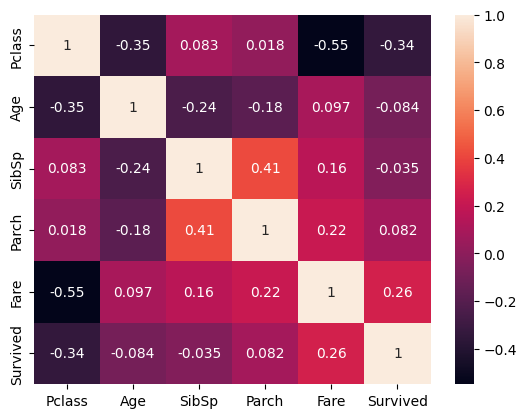

In [37]:
corr = pd.concat([X_imputed[num_cols], y], axis=1).corr()
sns.heatmap(corr, annot=True)

/tmp/ipykernel_3076536/1964144493.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')


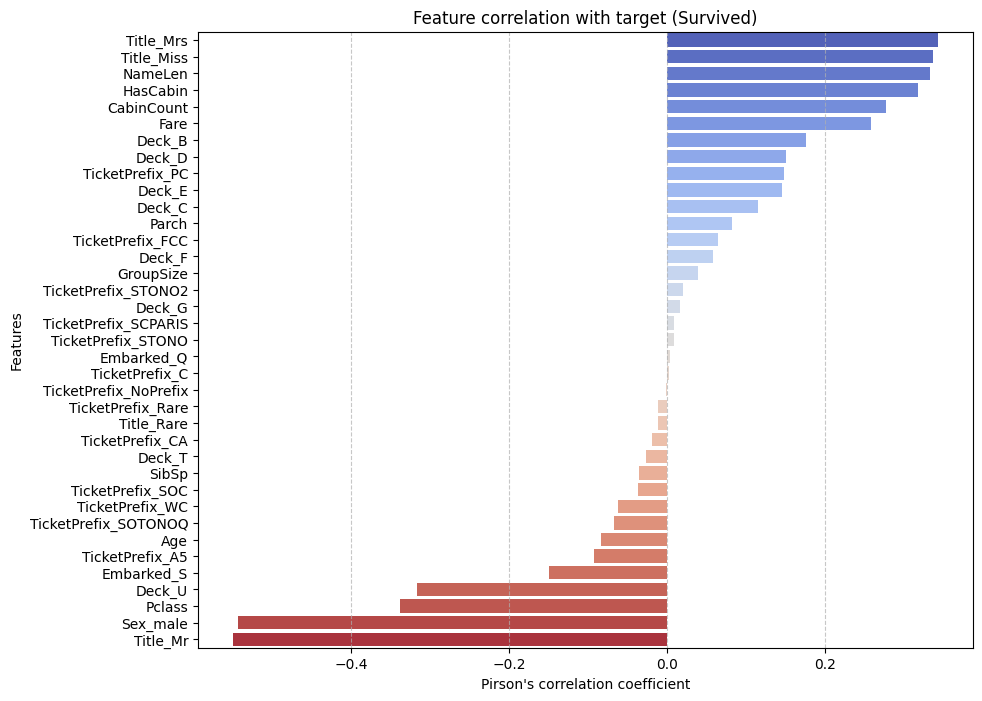

In [38]:
target_corr = X_imputed.corrwith(y).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.title('Feature correlation with target (Survived)')
plt.xlabel("Pirson's correlation coefficient")
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Base models

### Logistic regression 

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y,
    test_size=0.2, 
    random_state=42, 
    stratify=y)

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [41]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [42]:
print(classification_report(y_val, lr_model.predict(X_val_scaled)))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [43]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [44]:
print(classification_report(y_val, lr_model.predict(X_val_scaled)))
print(classification_report(y_val, rf_model.predict(X_val)))

              precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Pclass        891 non-null    int64   
 1   Sex           891 non-null    category
 2   Age           714 non-null    float64 
 3   SibSp         891 non-null    int64   
 4   Parch         891 non-null    int64   
 5   Fare          891 non-null    float64 
 6   Embarked      891 non-null    category
 7   HasCabin      891 non-null    int64   
 8   Deck          891 non-null    category
 9   CabinCount    891 non-null    int64   
 10  GroupSize     891 non-null    int64   
 11  TicketPrefix  891 non-null    category
 12  NameLen       891 non-null    int64   
 13  Title         891 non-null    category
dtypes: category(5), float64(2), int64(7)
memory usage: 68.6 KB


## Boosting

### LightGBM general

In [46]:
from lightgbm import LGBMClassifier

In [47]:
X_raw = df
X_train_lgb, X_val_lgb, y_train_lgb, y_val_lgb = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
lgb_model = LGBMClassifier(random_state=42, verbose=-1)
lgb_model.fit(X_train_lgb, y_train_lgb)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [49]:
y_pred_lgb = lgb_model.predict(X_val_lgb)
print(classification_report(y_val_lgb, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.71      0.68      0.70        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.76       179
weighted avg       0.77      0.77      0.77       179



### GridSearch

In [50]:
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'num_leaves': [7, 15, 31, 63],
    'min_child_samples': [10, 20, 30, 40],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150, 200]
}

In [51]:
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib


lgb_base = LGBMClassifier(random_state=42, verbose=-1)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

n_combinations = np.prod([len(val) for val in param_grid.values()])
n_folds = cv_strategy.n_splits
total_fits = n_combinations * n_folds
print(f"Total number of iterations: {total_fits}")

with tqdm_joblib(tqdm(desc="Grid Search Progress", total=total_fits)):
    grid_search.fit(X_train_lgb, y_train_lgb)

print("Best parameters:", grid_search.best_params_)
print(f"best accuracy CV: {grid_search.best_score_:.4f}")

/home/mordrud/.local/share/mise/installs/python/3.11.15/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


Total number of iterations: 3840


Grid Search Progress:   0%|          | 0/3840 [00:00<?, ?it/s]

  0%|          | 0/3840 [00:00<?, ?it/s]

Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_samples': 30, 'n_estimators': 200, 'num_leaves': 7}
best accuracy CV: 0.8399


In [52]:
y_pred_lgb = grid_search.predict(X_val_lgb)
print(classification_report(y_val_lgb, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [54]:
y_pred_lgb

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [57]:
tdf = X_val_lgb.sample(5)

In [58]:
tdf

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Deck,CabinCount,GroupSize,TicketPrefix,NameLen,Title
271,3,male,25.0,0,0,0.0000,S,0,U,0,4,NoPrefix,28,Mr
375,1,female,NaN,1,0,82.1708,C,0,U,0,2,PC,37,Mrs
401,3,male,26.0,0,0,8.0500,S,0,U,0,1,NoPrefix,15,Mr
216,3,female,27.0,0,0,7.9250,S,0,U,0,1,STONO2,22,Miss
211,2,female,35.0,0,0,21.0000,S,0,U,0,1,FCC,26,Miss


In [61]:
import onnxruntime as ort
session = ort.InferenceSession('../artifacts/model.onnx')
categorical_features = ['Sex', 'Embarked', 'Deck', 'TicketPrefix', 'Title']

onnx_inputs = {}
for col in tdf.columns:
    if col in categorical_features:
        onnx_inputs[col] = tdf[col].astype(str).values.reshape(-1, 1)
    else:
        onnx_inputs[col] = tdf[col].values.reshape(-1, 1).astype(np.float32)

output_names = [out.name for out in session.get_outputs()]

onnx_outputs = session.run(output_names, onnx_inputs)

In [62]:
onnx_outputs

[array([0, 1, 0, 1, 1], dtype=int64),
 array([[0.9961726 , 0.00382739],
        [0.0025447 , 0.9974553 ],
        [0.84308434, 0.15691566],
        [0.3784606 , 0.6215394 ],
        [0.25204837, 0.7479516 ]], dtype=float32)]

In [63]:
tdf.to_dict()

{'Pclass': {271: 3, 375: 1, 401: 3, 216: 3, 211: 2},
 'Sex': {271: 'male',
  375: 'female',
  401: 'male',
  216: 'female',
  211: 'female'},
 'Age': {271: 25.0, 375: nan, 401: 26.0, 216: 27.0, 211: 35.0},
 'SibSp': {271: 0, 375: 1, 401: 0, 216: 0, 211: 0},
 'Parch': {271: 0, 375: 0, 401: 0, 216: 0, 211: 0},
 'Fare': {271: 0.0, 375: 82.1708, 401: 8.05, 216: 7.925, 211: 21.0},
 'Embarked': {271: 'S', 375: 'C', 401: 'S', 216: 'S', 211: 'S'},
 'HasCabin': {271: 0, 375: 0, 401: 0, 216: 0, 211: 0},
 'Deck': {271: 'U', 375: 'U', 401: 'U', 216: 'U', 211: 'U'},
 'CabinCount': {271: 0, 375: 0, 401: 0, 216: 0, 211: 0},
 'GroupSize': {271: 4, 375: 2, 401: 1, 216: 1, 211: 1},
 'TicketPrefix': {271: 'NoPrefix',
  375: 'PC',
  401: 'NoPrefix',
  216: 'STONO2',
  211: 'FCC'},
 'NameLen': {271: 28, 375: 37, 401: 15, 216: 22, 211: 26},
 'Title': {271: 'Mr', 375: 'Mrs', 401: 'Mr', 216: 'Miss', 211: 'Miss'}}

In [ ]:
test_df = pd.read_csv('../data/train.csv').drop(columns=['PassengerId'])

In [118]:
sample = test_df.sample(3)
sample

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
657,0,3,"Bourke, Mrs. John (Catherine)",female,32.0,1,1,364849,15.5,NaN,Q
842,1,1,"Serepeca, Miss. Augusta",female,30.0,0,0,113798,31.0,NaN,C
577,1,1,"Silvey, Mrs. William Baird (Alice Munger)",female,39.0,1,0,13507,55.9,E44,S


In [119]:
y = sample['Survived'].values
y

array([0, 1, 1])

In [120]:
sample = sample.drop(columns=['Survived'])
sample_dict = sample.where(pd.notnull(sample), None).to_dict(orient='records')

In [132]:
import requests

def predict(data):
    url = 'http://127.0.0.1:8000/predict_batch'

    response = requests.post(url, json=data)

    return response.json()


In [133]:
predict(sample_dict)

[{'survived': 0, 'proba': 0.13751018047332764},
 {'survived': 1, 'proba': 0.9505357146263123},
 {'survived': 1, 'proba': 0.9937719702720642}]

In [65]:
import pickle
import sys
import os
sys.path.append(os.path.abspath('app'))
from features import FeatureExtractor
with open("../artifacts/extractor.pkl", "rb") as f:
    extractor = pickle.load(f)


In [ ]:
raw_df = pd.read_csv("../data/test.csv")

In [ ]:
TRITON_STRING_TO_NUMPY = {
    "TYPE_BOOL": bool,
    "TYPE_UINT8": np.uint8,
    "TYPE_UINT16": np.uint16,
    "TYPE_UINT32": np.uint32,
    "TYPE_UINT64": np.uint64,
    "TYPE_INT8": np.int8,
    "TYPE_INT16": np.int16,
    "TYPE_INT32": np.int32,
    "TYPE_INT64": np.int64,
    "TYPE_FP16": np.float16,
    "TYPE_FP32": np.float32,
    "TYPE_FP64": np.float64,
    "TYPE_STRING": np.object_,
}

In [ ]:
def numpy_to_triton_type(data_type):
    if data_type == np.bool_:
        return 1
    elif data_type == np.uint8:
        return 2
    elif data_type == np.uint16:
        return 3
    elif data_type == np.uint32:
        return 4
    elif data_type == np.uint64:
        return 5
    elif data_type == np.int8:
        return 6
    elif data_type == np.int16:
        return 7
    elif data_type == np.int32:
        return 8
    elif data_type == np.int64:
        return 9
    elif data_type == np.float16:
        return 10
    elif data_type == np.float32:
        return 11
    elif data_type == np.float64:
        return 12
    elif data_type == np.object_ or data_type == np.bytes_:
        return 13

In [ ]:
for name in df.columns:
    tp = list(TRITON_STRING_TO_NUMPY.keys())[numpy_to_triton_type(df[name].dtype)-1]

    print('{ '+f"name: {name}, data_type: {tp}, dims: [ 1 ]"+' }')

{ name: Pclass, data_type: TYPE_INT64, dims: [ 1 ] }
{ name: Sex, data_type: TYPE_STRING, dims: [ 1 ] }
{ name: Age, data_type: TYPE_FP64, dims: [ 1 ] }
{ name: SibSp, data_type: TYPE_INT64, dims: [ 1 ] }
{ name: Parch, data_type: TYPE_INT64, dims: [ 1 ] }
{ name: Fare, data_type: TYPE_FP64, dims: [ 1 ] }
{ name: Embarked, data_type: TYPE_STRING, dims: [ 1 ] }
{ name: HasCabin, data_type: TYPE_INT64, dims: [ 1 ] }
{ name: Deck, data_type: TYPE_STRING, dims: [ 1 ] }
{ name: CabinCount, data_type: TYPE_INT64, dims: [ 1 ] }
{ name: GroupSize, data_type: TYPE_INT64, dims: [ 1 ] }
{ name: TicketPrefix, data_type: TYPE_STRING, dims: [ 1 ] }
{ name: NameLen, data_type: TYPE_INT64, dims: [ 1 ] }
{ name: Title, data_type: TYPE_STRING, dims: [ 1 ] }
